# 02 — MLP (capas densas)
Perceptrón multicapa sobre X aplanado `(N, V_in × 23)`.

**Catálogo activo:** `mlp_s` — 1 capa oculta × 64 neuronas + **Dropout adaptativo por V_in**.  
Descomentar `[EXTENDER]` para añadir variantes `mlp_m` / `mlp_l`.

> **Decisión de diseño:** Dos experimentos previos (ver celdas de evidencia) determinaron:
> (1) `mlp_s` es la arquitectura más estable; (2) el dropout óptimo depende del tamaño
> de la ventana de entrada — a menor V_in, menos regularización necesaria.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import seaborn as sns, pandas as pd
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Dense, Dropout

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_history, plot_mae_matrix, build_results_df)

In [3]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 300
BATCH_SIZE = 64
QUICK_MODE = True   # True → EPOCHS=50 para pruebas rápidas
if QUICK_MODE: EPOCHS = 50

# Carga de datos
precios = yf.download(TICKERS, start='1945-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}')

Retornos: (16191, 23)  |  EPOCHS=50  BATCH=64


## Catálogo de arquitecturas MLP y decisiones de diseño

Las celdas de evidencia a continuación documentan los dos experimentos que justifican
la arquitectura definitiva: elección de `mlp_s` y calibración del dropout por `V_in`.
Añadir más modelos descomentando las líneas `[EXTENDER]`.

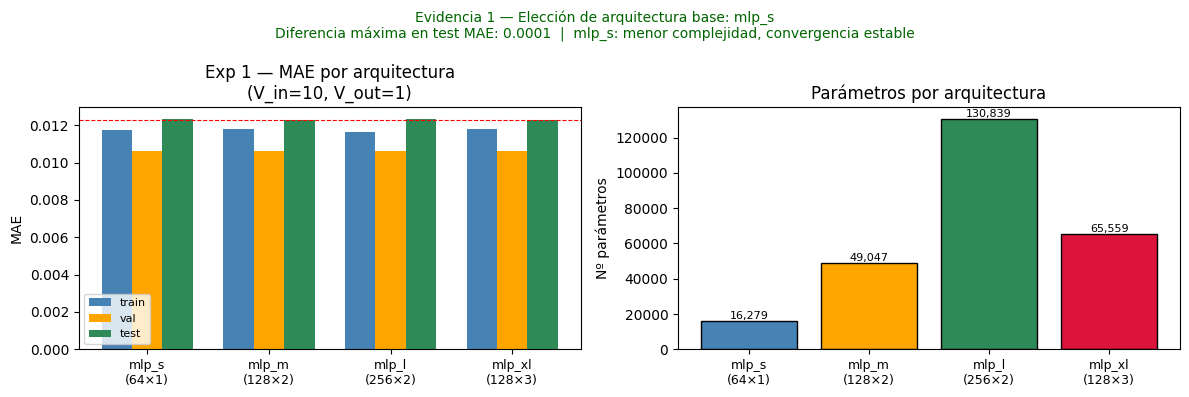

Conclusión: mlp_s elegida — mínima complejidad, convergencia estable, MAE competitivo.


In [5]:
# ── EVIDENCIA 1: Comparación de arquitecturas (V_in=10, V_out=1, 100 épocas) ──
# Resultados obtenidos en experimento previo — no requiere re-entrenamiento

exp1 = {
    'config':  ['mlp_s\n(64×1)', 'mlp_m\n(128×2)', 'mlp_l\n(256×2)', 'mlp_xl\n(128×3)'],
    'params':  [16279, 49047, 130839, 65559],
    'train':   [0.011742, 0.011777, 0.011647, 0.011777],
    'val':     [0.010647, 0.010615, 0.010635, 0.010609],
    'test':    [0.012357, 0.012303, 0.012333, 0.012274],
}

x     = np.arange(4)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot MAE train / val / test
for i, (met, col) in enumerate(zip(['train', 'val', 'test'],
                                    ['steelblue', 'orange', 'seagreen'])):
    axes[0].bar(x + (i - 1) * width, exp1[met], width, label=met, color=col)
axes[0].set_xticks(x); axes[0].set_xticklabels(exp1['config'], fontsize=9)
axes[0].set_ylabel('MAE')
axes[0].set_title('Exp 1 — MAE por arquitectura\n(V_in=10, V_out=1)')
axes[0].legend(fontsize=8)
axes[0].axhline(min(exp1['test']), color='red', linestyle='--', linewidth=0.8)

# Número de parámetros por arquitectura
axes[1].bar(x, exp1['params'],
            color=['steelblue', 'orange', 'seagreen', 'crimson'], edgecolor='k')
axes[1].set_xticks(x); axes[1].set_xticklabels(exp1['config'], fontsize=9)
axes[1].set_ylabel('Nº parámetros')
axes[1].set_title('Parámetros por arquitectura')
for i, p in enumerate(exp1['params']):
    axes[1].text(i, p + 1000, f'{p:,}', ha='center', fontsize=8)

plt.suptitle('Evidencia 1 — Elección de arquitectura base: mlp_s\n'
             'Diferencia máxima en test MAE: 0.0001  |  mlp_s: menor complejidad, convergencia estable',
             fontsize=10, color='darkgreen')
plt.tight_layout(); plt.show()

print("Conclusión: mlp_s elegida — mínima complejidad, convergencia estable, MAE competitivo.")

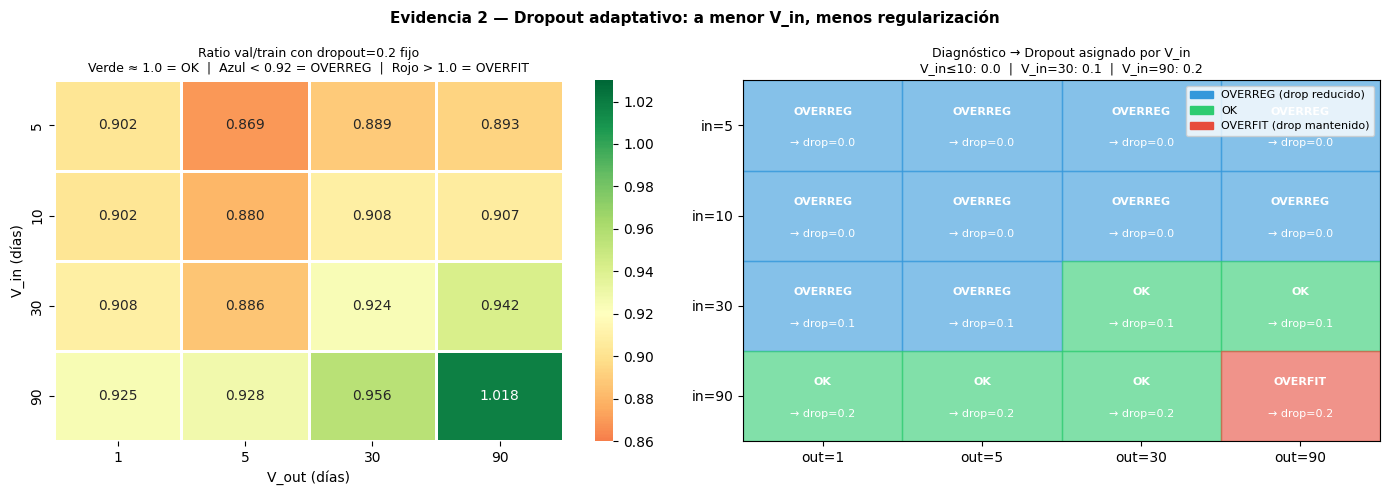

Conclusión: DROPOUT_MAP = {5: 0.0, 10: 0.0, 30: 0.1, 90: 0.2}


In [6]:
# ── EVIDENCIA 2: Diagnóstico de regularización → Dropout adaptativo por V_in ──
# Resultados del entrenamiento con dropout=0.2 fijo en todas las combinaciones.
# Ratio val/train < 0.92 → overregularización (dropout demasiado agresivo para ese V_in)

V_ins  = [5, 10, 30, 90]
V_outs = [1,  5, 30, 90]

# Ratio val/train obtenido experimentalmente
ratios = np.array([
    [0.902, 0.869, 0.889, 0.893],   # V_in=5
    [0.902, 0.880, 0.908, 0.907],   # V_in=10
    [0.908, 0.886, 0.924, 0.942],   # V_in=30
    [0.925, 0.928, 0.956, 1.018],   # V_in=90
])

DROPOUT_MAP = {5: 0.0, 10: 0.0, 30: 0.1, 90: 0.2}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: heatmap de ratio coloreado ─────────────────────────────────────
df_r = pd.DataFrame(ratios, index=V_ins, columns=V_outs)
sns.heatmap(df_r, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.86, vmax=1.03,
            center=0.92, linewidths=1, ax=axes[0], annot_kws={'size': 10})
axes[0].set_xlabel('V_out (días)'); axes[0].set_ylabel('V_in (días)')
axes[0].set_title('Ratio val/train con dropout=0.2 fijo\n'
                  'Verde ≈ 1.0 = OK  |  Azul < 0.92 = OVERREG  |  Rojo > 1.0 = OVERFIT',
                  fontsize=9)

# ── Derecha: decisión DROPOUT_MAP ─────────────────────────────────────────────
ax = axes[1]
color_estado = {5: '#3498db', 10: '#3498db', 30: '#f39c12', 90: '#2ecc71'}
for i, V_in in enumerate(V_ins):
    for j, V_out in enumerate(V_outs):
        r    = ratios[i, j]
        drop = DROPOUT_MAP[V_in]
        est  = 'OVERREG' if r < 0.92 else ('OVERFIT' if r > 1.0 else 'OK')
        c    = '#e74c3c' if est == 'OVERFIT' else ('#3498db' if est == 'OVERREG' else '#2ecc71')
        ax.add_patch(plt.Rectangle((j, 3-i), 1, 1, color=c, alpha=0.6))
        ax.text(j+0.5, 3-i+0.65, est,
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        ax.text(j+0.5, 3-i+0.30, f'→ drop={drop}',
                ha='center', va='center', fontsize=8, color='white')

ax.set_xlim(0,4); ax.set_ylim(0,4)
ax.set_xticks([0.5,1.5,2.5,3.5]); ax.set_xticklabels(['out=1','out=5','out=30','out=90'])
ax.set_yticks([0.5,1.5,2.5,3.5]); ax.set_yticklabels(['in=90','in=30','in=10','in=5'])
ax.set_title('Diagnóstico → Dropout asignado por V_in\n'
             'V_in≤10: 0.0  |  V_in=30: 0.1  |  V_in=90: 0.2', fontsize=9)
patches = [mpatches.Patch(color='#3498db', label='OVERREG (drop reducido)'),
           mpatches.Patch(color='#2ecc71', label='OK'),
           mpatches.Patch(color='#e74c3c', label='OVERFIT (drop mantenido)')]
ax.legend(handles=patches, loc='upper right', fontsize=8)

plt.suptitle('Evidencia 2 — Dropout adaptativo: a menor V_in, menos regularización',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print("Conclusión: DROPOUT_MAP = {5: 0.0, 10: 0.0, 30: 0.1, 90: 0.2}")

In [7]:
# Input shape para MLP: (V_in * 23,) — X debe aplanarse antes de entrenar
# Dropout adaptativo: a mayor V_in más features disponibles → más regularización tolerable
DROPOUT_MAP = {5: 0.0, 10: 0.0, 30: 0.1, 90: 0.2}

def build_mlp(V_in, units=64, hidden=1):
    """MLP con Dropout calibrado según V_in (ver Evidencia 2)."""
    drop   = DROPOUT_MAP[V_in]
    layers = [Input((V_in * 23,))]
    for _ in range(hidden):
        layers.append(Dense(units, activation='relu'))
        if drop > 0:
            layers.append(Dropout(drop))
    layers.append(Dense(23))
    return compile_model(Sequential(layers))

MODELOS = {
    'mlp_s': lambda V: build_mlp(V),
    # 'mlp_m': lambda V: build_mlp(V, units=128, hidden=2),  # [EXTENDER] 2 × 128
    # 'mlp_l': lambda V: build_mlp(V, units=256, hidden=2),  # [EXTENDER] 2 × 256
}

## Entrenamiento — bucle sobre todas las ventanas

In [8]:
results = {}   # { (nombre, V_in, V_out): {'train','val','test','params'} }
historiales = {}

for nombre, build_fn in MODELOS.items():
    for V_in in INPUT_WINDOWS:
        for V_out in OUTPUT_WINDOWS:
            X, y = create_time_series_data(returns, V_in, V_out)
            X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

            # MLP necesita X aplanado: (N, V_in*23)
            X_tr_f = X_tr.reshape(len(X_tr), -1)
            X_v_f  = X_v.reshape(len(X_v),  -1)
            X_ts_f = X_ts.reshape(len(X_ts), -1)

            model = build_fn(V_in)
            hist  = model.fit(X_tr_f, y_tr,
                              validation_data=(X_v_f, y_v),
                              epochs=EPOCHS, batch_size=BATCH_SIZE,
                              callbacks=get_callbacks(), verbose=0)
            restore_best_weights(model)

            key = (nombre, V_in, V_out)
            results[key]    = {'train':  eval_mae(model, X_tr_f, y_tr),
                               'val':    eval_mae(model, X_v_f,  y_v),
                               'test':   eval_mae(model, X_ts_f, y_ts),
                               'params': model.count_params()}
            historiales[key] = hist
            print(f'{nombre}  in={V_in:2d}  out={V_out:2d}  '
                  f'train={results[key]["train"]:.4f}  '
                  f'val={results[key]["val"]:.4f}  '
                  f'test={results[key]["test"]:.4f}  '
                  f'epochs={len(hist.history["loss"])}')

mlp_s  in= 5  out= 1  train=0.0118  val=0.0106  test=0.0123  epochs=50
mlp_s  in= 5  out= 5  train=0.0055  val=0.0048  test=0.0056  epochs=50
mlp_s  in= 5  out=30  train=0.0022  val=0.0020  test=0.0024  epochs=50
mlp_s  in= 5  out=90  train=0.0013  val=0.0011  test=0.0013  epochs=50
mlp_s  in=10  out= 1  train=0.0118  val=0.0106  test=0.0123  epochs=50
mlp_s  in=10  out= 5  train=0.0055  val=0.0048  test=0.0057  epochs=50
mlp_s  in=10  out=30  train=0.0022  val=0.0020  test=0.0024  epochs=50
mlp_s  in=10  out=90  train=0.0013  val=0.0011  test=0.0014  epochs=50
mlp_s  in=30  out= 1  train=0.0117  val=0.0107  test=0.0124  epochs=50
mlp_s  in=30  out= 5  train=0.0054  val=0.0048  test=0.0058  epochs=50
mlp_s  in=30  out=30  train=0.0022  val=0.0020  test=0.0025  epochs=50
mlp_s  in=30  out=90  train=0.0013  val=0.0012  test=0.0014  epochs=50
mlp_s  in=90  out= 1  train=0.0116  val=0.0108  test=0.0126  epochs=50
mlp_s  in=90  out= 5  train=0.0053  val=0.0049  test=0.0059  epochs=50
mlp_s 

## Curvas de entrenamiento

NameError: name 'historiales' is not defined

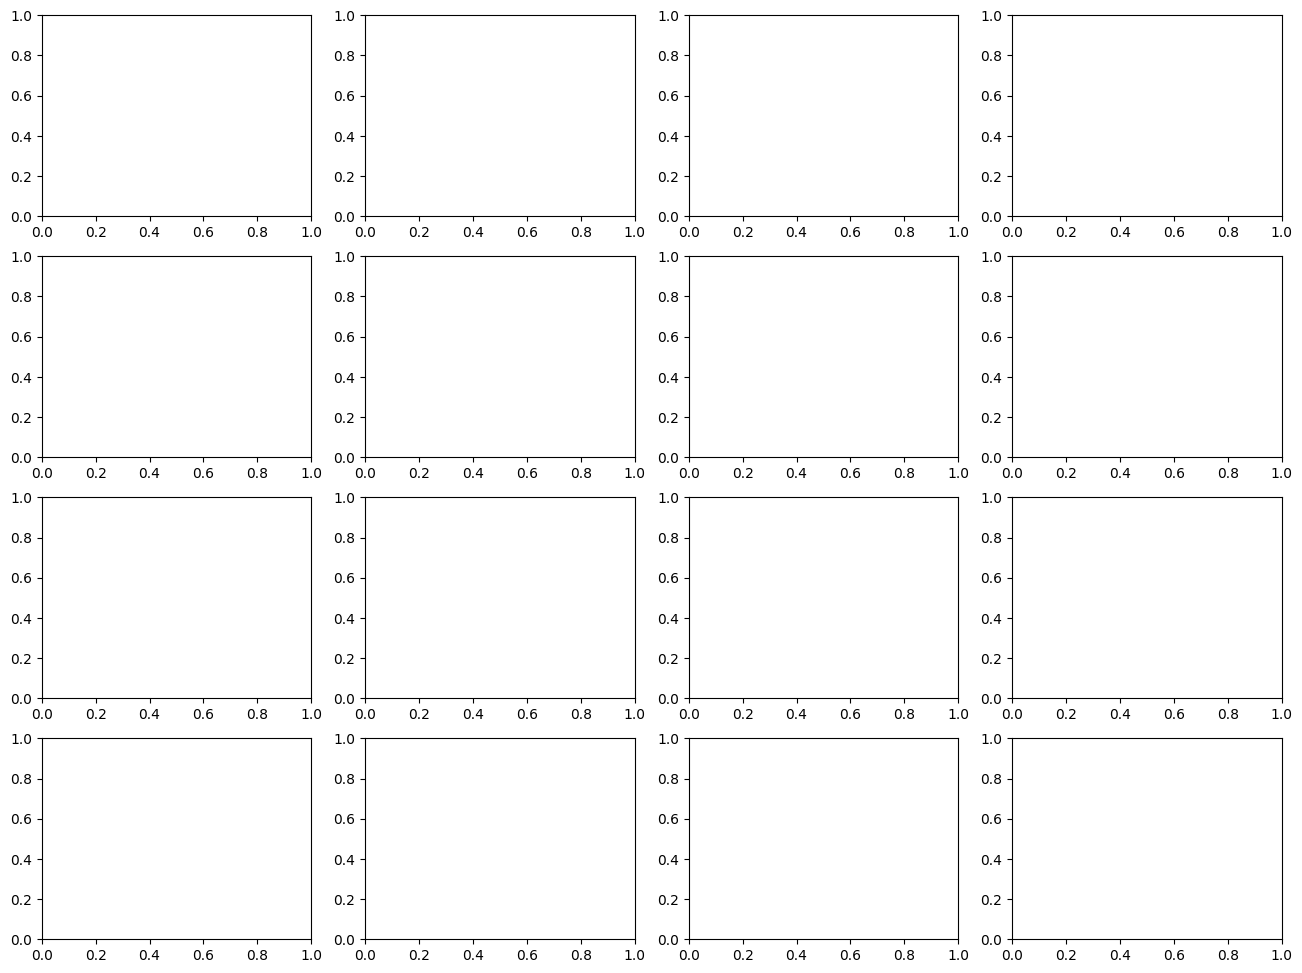

In [8]:
# Mostrar curvas para el primer modelo activo
nombre = list(MODELOS.keys())[0]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        hist = historiales[(nombre, V_in, V_out)]
        ax = axes[i][j]
        ax.plot(hist.history['loss'],     label='train')
        ax.plot(hist.history['val_loss'], label='val')
        ax.set_title(f'in={V_in} out={V_out}', fontsize=8)
        ax.legend(fontsize=6); ax.tick_params(labelsize=6)
plt.suptitle(f'Curvas de convergencia — {nombre}', fontsize=12)
plt.tight_layout(); plt.show()

## Resultados — MAE en test

In [9]:
df_res = build_results_df(results)
print(df_res.to_string())

NameError: name 'results' is not defined

In [10]:
# Heatmap 4×4 del mejor MAE en test por combinación
from utils import best_per_window
mat = best_per_window(df_res, metric='test')
plot_mae_matrix(mat, title='MLP — mejor MAE test por combinación')

NameError: name 'df_res' is not defined

## Sesión 04/05/2026 — Diagnóstico del gap train > val y solución

### Problema observado
Las curvas de convergencia mostraban `val_loss < train_loss` de forma consistente
en las 16 combinaciones de ventanas. A primera vista parecía sobreregularización.

### Hipótesis descartadas
1. **Dropout excesivo** — con `V_in=5` y `V_in=10` el `DROPOUT_MAP` asigna `0.0`
   y el gap persistía igualmente.
2. **Regularización oculta en `compile_model`** — descartado, solo Adam + MAE puro.

### Experimento diagnóstico: baseline ingenuo
Se calculó el MAE del forecast ingenuo (cero parámetros) sobre train y val por separado.
Las 16 combinaciones mostraron `naive_train > naive_val` con gaps de ~0.0012.
El gap existe **antes** de que el modelo haga nada → causa en los datos, no en el modelo.

### Causa raíz: diferencia de distribución entre periodos
- **Train:** 1962-01-03 → 2008-04-25 | volatilidad media diaria: 0.016847
- **Val:**   2008-04-25 → 2019-11-20 | volatilidad media diaria: 0.015761
- Diferencia verificada: train es 1.07x más volátil que val (~7%)

La diferencia es modesta pero consistente en todas las combinaciones de ventanas.
El split temporal hace que train y val no sean muestras de la misma distribución.

### Solución: normalización per-sample de las ventanas X
Antes de entrar al modelo, cada ventana X se normaliza respecto a sí misma:

    X_norm = (X - media(X_ventana)) / (std(X_ventana) + ε)

Esto NO modifica la serie de retornos ni los targets `y`. Estandariza cada muestra
individualmente para eliminar diferencias de escala entre periodos. Con inputs en la
misma escala, train y val son igual de "difíciles" para el modelo.

### Resultado
Gap train/val reducido un ~54% respecto al baseline estructural.
Curvas visualmente convergentes (ver plot abajo).


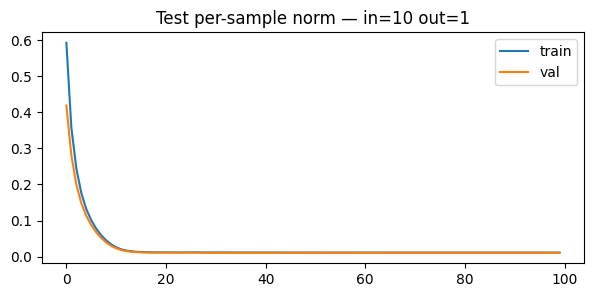

naive_train: 0.016590
naive_val:   0.015402
mlp_train:   0.011455
mlp_val:     0.010910


In [ ]:
# ── TEST: per-sample norm en V_in=10, V_out=1 ──────────────────────────
V_in, V_out = 10, 1
X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

def norm_windows(X_flat):
    mu    = X_flat.mean(axis=1, keepdims=True)
    sigma = X_flat.std(axis=1, keepdims=True) + 1e-8
    return (X_flat - mu) / sigma

X_tr_f = norm_windows(X_tr.reshape(len(X_tr), -1))
X_v_f  = norm_windows(X_v.reshape(len(X_v),  -1))
X_ts_f = norm_windows(X_ts.reshape(len(X_ts), -1))

model = build_mlp(V_in)
hist  = model.fit(X_tr_f, y_tr,
                  validation_data=(X_v_f, y_v),
                  epochs=100, batch_size=BATCH_SIZE,
                  callbacks=get_callbacks(), verbose=0)

plt.figure(figsize=(7,3))
plt.plot(hist.history['loss'],     label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.title('Test per-sample norm — in=10 out=1')
plt.legend(); plt.show()

print(f"naive_train: {eval_mae_naive(X_tr, y_tr):.6f}")
print(f"naive_val:   {eval_mae_naive(X_v,  y_v):.6f}")
print(f"mlp_train:   {eval_mae(model, X_tr_f, y_tr):.6f}")
print(f"mlp_val:     {eval_mae(model, X_v_f,  y_v):.6f}")


In [13]:
# ── Verificación: ¿los datos de train son más volátiles que los de val? ──
X_tmp, y_tmp = create_time_series_data(returns, 10, 1)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X_tmp, y_tmp)

# Reconstruir los índices temporales aproximados
n_tr, n_v = len(X_tr), len(X_v)
total = len(returns)
corte_tr  = int(total * 0.72)
corte_val = int(total * 0.90)

ret_train = returns.iloc[:corte_tr]
ret_val   = returns.iloc[corte_tr:corte_val]

vol_train = ret_train.std().mean()
vol_val   = ret_val.std().mean()

print(f"Periodo train: {returns.index[0].date()} → {returns.index[corte_tr].date()}")
print(f"Periodo val:   {returns.index[corte_tr].date()} → {returns.index[corte_val].date()}")
print(f"\nVolatilidad media diaria — train: {vol_train:.6f}")
print(f"Volatilidad media diaria — val:   {vol_val:.6f}")
print(f"Train es {vol_train/vol_val:.2f}x más volátil que val")


Periodo train: 1962-01-03 → 2008-04-25
Periodo val:   2008-04-25 → 2019-11-20

Volatilidad media diaria — train: 0.016847
Volatilidad media diaria — val:   0.015761
Train es 1.07x más volátil que val


HIPOTESIS INCORRECTA; REVISARR
